In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os

c:\Users\Khushbu.Kushvaha\Desktop\Kk\Langgraph_learn\my_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class ParentState(TypedDict):
    question: str
    answer_eng: str
    answer_hindi: str

In [5]:
llm = ChatOpenAI(
    model="nvidia/nemotron-3-nano-30b-a3b:free",   # or any OpenRouter model
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

In [15]:
def translate_text(state: ParentState):
    prompt = f"""
        Translate the following text to Hindi. Keep it natural and clear. Do not add extra content. 
        Text: {state['answer_eng']}
    """.strip()

    translate_text = llm.invoke(prompt).content

    return {'answer_hindi': translate_text}

In [16]:
## subgraph builder

subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()


In [17]:
def generate_answer(state: ParentState):
    answer = llm.invoke(f'you are a helpful assistant. Answer clearly. Question: {state['question']}').content
    return {'answer_eng': answer}

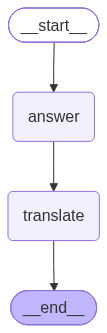

In [18]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node('answer', generate_answer)
parent_builder.add_node('translate', subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

graph = parent_builder.compile()

graph

In [19]:
res = graph.invoke({'question':'What is Winner Mindset'})

In [20]:
res

{'question': 'What is Winner Mindset',
 'answer_eng': 'The **Winner Mindset** isn\'t about winning at all costs—it\'s about a **growth-oriented, resilient, and process-focused way of thinking** that leads to sustained success and personal fulfillment. Here’s a clear breakdown:\n\n---\n\n### 🔑 **Core Definition**  \nA Winner Mindset is a **mental framework** where:  \n- **Success is defined by effort, growth, and learning** (not just outcomes).  \n- **Failure is seen as feedback**, not a reflection of self.  \n- **Focus is on progress**, not perfection.  \n- **Resilience and adaptability** drive action through challenges.  \n\n---\n\n### 🧠 **Key Elements of a Winner Mindset**  \n| Concept                | What It Means                                                                 | What It *Doesn’t* Mean                          |\n|------------------------|-------------------------------------------------------------------------------|------------------------------------------------|